In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from zlib import crc32
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import  RandomForestClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator
from sklearn.base import TransformerMixin
from sklearn.utils.validation import check_array ,check_is_fitted
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("spam.csv",encoding="latin-1")

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   v1      5572 non-null   str  
 1   v2      5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB
None 
 v1
ham     4825
spam     747
Name: count, dtype: int64


 1960    Guess what! Somebody you know secretly fancies...
486     FREE MESSAGE Activate your 500 FREE Text Messa...
3860    Free Msg: Ringtone!From: http://tms. widelive....
3090    LORD OF THE RINGS:RETURN OF THE KING in store ...
4733    Buy Space Invaders 4 a chance 2 win orig Arcad...
1829    Hottest pics straight to your phone!! See me g...
3976    Great NEW Offer - DOUBLE Mins & DOUBLE Txt on ...
814     U were outbid by simonwatson5120 on the Shinco...
3124    1st wk FREE! Gr8 tones str8 2 u each wk. Txt N...
4795    URGENT This is our 2nd attempt to contact U. Y...
Name: v2, dtype: str


<Axes: xlabel='v1', ylabel='Count'>

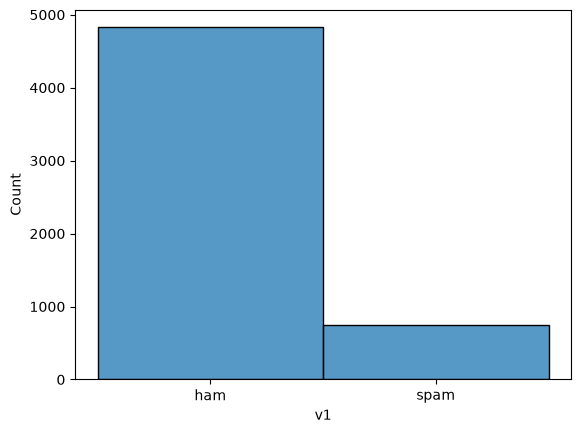

In [5]:
print(df.info(),"\n",df["v1"].value_counts())
print("\n\n",df["v2"][df["v1"] == "spam"].sample(10))
sns.histplot(data=df,x="v1")

In [6]:
print("Duplicated : ",df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("\nDuplicated : ",df.duplicated().sum())

Duplicated :  403

Duplicated :  0


In [7]:
rename_mapping = {
    "v1" : "label",
    "v2" : "text"
}
df.rename(columns = rename_mapping,inplace=True)
print(df.columns)
oe = OrdinalEncoder()
df["label"] = oe.fit_transform(df[["label"]])

Index(['label', 'text'], dtype='str')


# The dataset doesn't have any direct mathematical or even categorical proportions. So we do :
# Text Procceing

In [8]:
X = df["text"]
y = df["label"]
X_train , X_test, y_train , y_test = train_test_split(X,y,random_state=25,stratify=y)

In [9]:
model1 = Pipeline([
    ("preproccesor",TfidfVectorizer()),
    ("model",LogisticRegression())
])
model1.fit(X_train,y_train)
y_pred = model1.predict(X_test)
print("Testing Model 1 ...\n\n","Accuracy: ",cross_val_score(model1,X_test,y_test,cv=5,scoring="accuracy").mean(),"\n\nConfusion Matrix : \n",
confusion_matrix(y_test,y_pred),"\n\nPrecision :",precision_score(y_test,y_pred),"\nrecall : ",recall_score(y_test,y_pred),"\n F1 Score : ",f1_score(y_test,y_pred))


Testing Model 1 ...

 Accuracy:  0.9187991978689652 

Confusion Matrix : 
 [[1129    1]
 [  40  123]] 

Precision : 0.9919354838709677 
recall :  0.754601226993865 
 F1 Score :  0.8571428571428571


In [10]:
model2 = Pipeline([
    ("preproccesor",TfidfVectorizer()),
    ("model", MultinomialNB())
])
model2.fit(X_train,y_train)
y_pred = model2.predict(X_test)
print("Testing Model 2 ...\n\n","Accuracy: ",cross_val_score(model2,X_test,y_test,cv=5,scoring="accuracy").mean(),"\n\nConfusion Matrix : \n",
      confusion_matrix(y_test,y_pred),"\n\nPrecision :",precision_score(y_test,y_pred),"\nrecall : ",recall_score(y_test,y_pred),"\n F1 Score : ",f1_score(y_test,y_pred))

Testing Model 2 ...

 Accuracy:  0.9095088443925652 

Confusion Matrix : 
 [[1130    0]
 [  70   93]] 

Precision : 1.0 
recall :  0.5705521472392638 
 F1 Score :  0.7265625


In [11]:
model3 = Pipeline([
    ("preproccesor",TfidfVectorizer()),
    ("model", RandomForestClassifier())
])
model3.fit(X_train,y_train)
y_pred = model3.predict(X_test)
print("Testing Model 3 ...\n\n","Accuracy: ",cross_val_score(model3,X_test,y_test,cv=5,scoring="accuracy").mean(),"\n\nConfusion Matrix : \n",
      confusion_matrix(y_test,y_pred),"\n\nPrecision :",precision_score(y_test,y_pred),"\nrecall : ",recall_score(y_test,y_pred),"\n F1 Score : ",f1_score(y_test,y_pred))

Testing Model 3 ...

 Accuracy:  0.9450749753075334 

Confusion Matrix : 
 [[1130    0]
 [  35  128]] 

Precision : 1.0 
recall :  0.7852760736196319 
 F1 Score :  0.8797250859106529


# optimizating model 3 (RandomForestClassifier) by finding best training parameters

In [12]:
params = {
    "model__max_depth":[1,2,3,5,8,15,30],
    "model__min_samples_leaf":[1,2,5,10,15,28],
    "model__min_samples_split":[1,5,10,15,25,30]
}
print("Finding Best parameters for Model3 (RandomForestClassifier) ... \n\n")
gr = GridSearchCV(model3,param_grid=params,scoring="f1")
gr.fit(X_train,y_train)
print("Best Parameters : ",gr.best_params_,"\nBest f1 score : ",gr.best_score_)
model3 = gr.best_estimator_
y_pred = model3.predict(X_test)
print("\n\nTesting the new version of Model 3 ...\n\n","Accuracy: ",cross_val_score(model3,X_test,y_test,cv=5,scoring="accuracy").mean(),"\n\nConfusion Matrix : \n",
      confusion_matrix(y_test,y_pred),"\n\nPrecision :",precision_score(y_test,y_pred),"\nrecall : ",recall_score(y_test,y_pred),"\n F1 Score : ",f1_score(y_test,y_pred))

Finding Best parameters for Model3 (RandomForestClassifier) ... 




c:\Users\Mohammad Amin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
210 fits failed out of a total of 1260.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
210 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Mohammad Amin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Mohammad Amin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
 

Best Parameters :  {'model__max_depth': 30, 'model__min_samples_leaf': 1, 'model__min_samples_split': 30} 
Best f1 score :  0.8487530460309689


Testing the new version of Model 3 ...

 Accuracy:  0.9381251683577265 

Confusion Matrix : 
 [[1130    0]
 [  49  114]] 

Precision : 1.0 
recall :  0.6993865030674846 
 F1 Score :  0.8231046931407943


In [ ]:
params = {
    "model__max_depth":[100,105,110],
    "model__min_samples_leaf":[1],
    "model__min_samples_split":[26,27,28]
}
gr2 = GridSearchCV(model3,param_grid=params,scoring="f1")
gr2.fit(X_train,y_train)
print("Best Parameters : ",gr2.best_params_,"\nBest f1 score : ",gr2.best_score_)

Best Parameters :  {'model__max_depth': 105, 'model__min_samples_leaf': 1, 'model__min_samples_split': 28} 
Best f1 score :  0.887853874313248


In [20]:
model3 = gr2.best_estimator_
y_pred = model3.predict(X_test)
print("\n\nTesting the new version of Model 3 ...\n\n","Accuracy: ",cross_val_score(model3,X_test,y_test,cv=5,scoring="accuracy").mean(),"\n\nConfusion Matrix : \n",
      confusion_matrix(y_test,y_pred),"\n\nPrecision :",precision_score(y_test,y_pred),"\nrecall : ",recall_score(y_test,y_pred),"\n F1 Score : ",f1_score(y_test,y_pred))



Testing the new version of Model 3 ...

 Accuracy:  0.9497231450719823 

Confusion Matrix : 
 [[1129    1]
 [  36  127]] 

Precision : 0.9921875 
recall :  0.7791411042944786 
 F1 Score :  0.872852233676976


# optimizating model 1 (LogisticRegression) by finding best training parameters

In [35]:

params = {
    "model__C": [0.1, 1, 10],
    "model__class_weight": [None, "balanced"],
    "model__penalty": ["l2"]
}
print("Finding Best parameters for Model1 (LogisticRegression) ... \n\n")
gr = GridSearchCV(model1,param_grid=params,scoring="accuracy")
gr.fit(X_train,y_train)
print("Best Parameters : ",gr.best_params_,"\nBest Accuracy score : ",gr.best_score_)
model1 = gr.best_estimator_
y_pred = model1.predict(X_test)
print("\n\nTesting the new version of Model 1 ...\n\n","Accuracy: ",cross_val_score(model1,X_test,y_test,cv=5,scoring="accuracy").mean(),"\n\nConfusion Matrix : \n",
confusion_matrix(y_test,y_pred),"\n\nPrecision :",precision_score(y_test,y_pred),"\nrecall : ",recall_score(y_test,y_pred),"\n F1 Score : ",f1_score(y_test,y_pred))

Finding Best parameters for Model1 (LogisticRegression) ... 


Best Parameters :  {'model__C': 10, 'model__class_weight': 'balanced', 'model__penalty': 'l2'} 
Best Accuracy score :  0.9855520452278016


Testing the new version of Model 1 ...

 Accuracy:  0.9721558768070396 

Confusion Matrix : 
 [[1121    9]
 [  18  145]] 

Precision : 0.9415584415584416 
recall :  0.8895705521472392 
 F1 Score :  0.9148264984227129
